# FLEXPART exercise — Does aerosol shape matter?

We compare FLEXPART simulations in which the **equivalent particle diameter, density, release and meteorology are kept constant**, while particle morphology is changed. This is very relevant for particles of same material but different shapes and sizes, such as microplastics!

> **If we have a large variability in shapes, which particle morphology remains airborne longer, and how does shape affect transport and deposition?**

Try these cases:

| Species | Morphology |
|---|---|
| 20 | 30 µm sphere |
| 21 | fibre, aspect ratio 10, averaged orientation |
| 22 | fibre, aspect ratio 50, averaged orientation |
| 23 | fibre, aspect ratio 50, horizontal orientation |
| 33 | flat film, averaged orientation |

Before looking at the results, write down your expected ranking from **shortest** to **longest atmospheric residence time**.

Compare total atmospheric burden with time, dry and wet deposition, and spatial transport patterns. 

In [228]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature



## 1. Find and load the FLEXPART output

Let's call the data 'grid_conc_YYYYMMDDHHMMSS_xx.nc'., with the xx indicating the number of the species. For example 020:  "grid_conc_YYYYMMDDHHMMSS_20.nc"
Change `DATA_DIR` if needed.

In [267]:
DATA_DIR = Path(".")

CASE_INFO = {
    "20": "Sphere 30 µm",
    "21": "Fibre AR=10",
    "22": "Fibre AR=50",
    "23": "Fibre AR=50, horiz orientation",
    "33": "Flat film",
}

### "Let's check if all files are there"
files = {}
for species, label in CASE_INFO.items():
    matches = sorted(DATA_DIR.glob(f"grid_conc_*_{species}.nc"))
    if matches:
        files[label] = matches[0]

print("Files found:")
for label, filename in files.items():
    print(f"  {label:32s} -> {filename}")

    


Files found:
  Sphere 30 µm                     -> grid_conc_20170925000000_20.nc
  Fibre AR=10                      -> grid_conc_20170925000000_21.nc
  Fibre AR=50                      -> grid_conc_20170925000000_22.nc
  Fibre AR=50, horiz orientation   -> grid_conc_20170925000000_23.nc
  Flat film                        -> grid_conc_20170925000000_33.nc


### What do we need to use?

- `spec001_mr`: atmospheric mass concentration
- `DD_spec001`: accumulated dry deposition
- `WD_spec001`: accumulated wet deposition
- `longitude`, `latitude`, `height`, `time`: coordinates



In [271]:
datasets = {label: xr.open_dataset(filename) for label, filename in files.items()}
for label, ds in datasets.items():
    print(label)
    for var in ("spec001_mr", "DD_spec001", "WD_spec001"):
        print(f"  {var:12s}: {ds[var].attrs.get('units', '')}")
        if var=="spec001_mr":
            long_name = ds[var].attrs.get("long_name", "")
            print(f"Name in SPECIES: {long_name} ")        

Sphere 30 µm
  spec001_mr  : ng m-3
Name in SPECIES: sphere_30u 
  DD_spec001  : 1e-12 kg m-2
  WD_spec001  : 1e-12 kg m-2
Fibre AR=10
  spec001_mr  : ng m-3
Name in SPECIES: fiber_AR_1 
  DD_spec001  : 1e-12 kg m-2
  WD_spec001  : 1e-12 kg m-2
Fibre AR=50
  spec001_mr  : ng m-3
Name in SPECIES: fiber_AR_5 
  DD_spec001  : 1e-12 kg m-2
  WD_spec001  : 1e-12 kg m-2
Fibre AR=50, horiz orientation
  spec001_mr  : ng m-3
Name in SPECIES: fiber_AR50 
  DD_spec001  : 1e-12 kg m-2
  WD_spec001  : 1e-12 kg m-2
Flat film
  spec001_mr  : ng m-3
Name in SPECIES: AEROSOL_fi 
  DD_spec001  : 1e-12 kg m-2
  WD_spec001  : 1e-12 kg m-2


## 2. Integrate the gridded output

Let's estimate the total

- **airborne mass** by integrating concentration over the 3-D grid;

Airborne mass gives at each time step the concentration of the suspended aerosol

- **dry-deposited mass** over the horizontal grid;

DD gives at each time step the dry depositon accumulated until that specific time step

- **wet-deposited mass** over the horizontal grid.

WD gives at each time step the wet depositon accumulated until that specific time step


In [231]:
plt.rcParams["figure.figsize"] = (9, 5) #Let's choose here the general sizes of our plots
EARTH_RADIUS = 6_371_000.0 # in meters

#With this we compute the area of grid
def gridcell_areas(ds):
    lon = ds.longitude.values
    lat = ds.latitude.values
    dlon_deg = abs(np.median(np.diff(lon)))
    dlat_deg = abs(np.median(np.diff(lat)))
    dlon = np.deg2rad(dlon_deg)
    lat1 = np.deg2rad(lat - dlat_deg / 2)
    lat2 = np.deg2rad(lat + dlat_deg / 2)
    area_lat = EARTH_RADIUS**2 * dlon * (np.sin(lat2) - np.sin(lat1))
    area = np.repeat(area_lat[:, None], len(lon), axis=1)
    return xr.DataArray(area,
                        coords={"latitude": ds.latitude, "longitude": ds.longitude},
                        dims=("latitude", "longitude"))

#With this we want to compute the thickness of the considered layer
def layer_thickness(ds):
    # FLEXPART gives us the TOP of each vertical output layer
    # The bottom of the first layer is the ground (0 m), for all other layers, the bottom is the top of the previous layer.
    layer_top = ds.height.values
    layer_bottom = np.concatenate(([0], layer_top[:-1]))
    thickness = layer_top - layer_bottom
    # Put the same vertical coordinate as the FLEXPART data
    thickness = xr.DataArray(
        thickness,
        coords={"height": ds.height},
        dims=["height"]
    )
    return thickness

def diagnostics(ds):
    area = gridcell_areas(ds)
    dz = layer_thickness(ds)

    # we make the conversion ng m-3 * m3 -> ng -> kg
    airborne = (ds["spec001_mr"] * area * dz).sum(
        ("height", "latitude", "longitude")) * 1e-12  #Here is integrated over all layers

    # same for deposition, we do 1e-12 kg m-2 * m2 -> kg
    dry = (ds["DD_spec001"] * area).sum(
        ("latitude", "longitude")) * 1e-12
    wet = (ds["WD_spec001"] * area).sum(
        ("latitude", "longitude")) * 1e-12

    return xr.Dataset({
        "airborne_kg": airborne,
        "dry_deposited_kg": dry,
        "wet_deposited_kg": wet
    })

diag = {label: diagnostics(ds) for label, ds in datasets.items()}

## 3. Atmospheric burden through time

Now that you have some useful functions, let's check how the morphology affects the distribution in concentration.

First thing to plot is the timeseries of the total airborne mass, for each morphology. 
This will tell you which one of those shapes is having, with the same mass, **the longest time of suspension**

## 4. Deposition fluxes through time

We want to check the same exact thing also in dry and wet deposition. 

-**How do you expect these deposition fluxes to behave with respect to the atmospheric burden?**

## 5. Maps of airborne material

Let's try also to get a comparison of the spatial distribution of these variables 

## 6. Comparison table at the final step
Let's take the last timestep of the simulation, integrating both in lat-lon and vertically, to obtain a table such as:

![Table](images/Table_ex.png)

## Solutions to 3 and 4

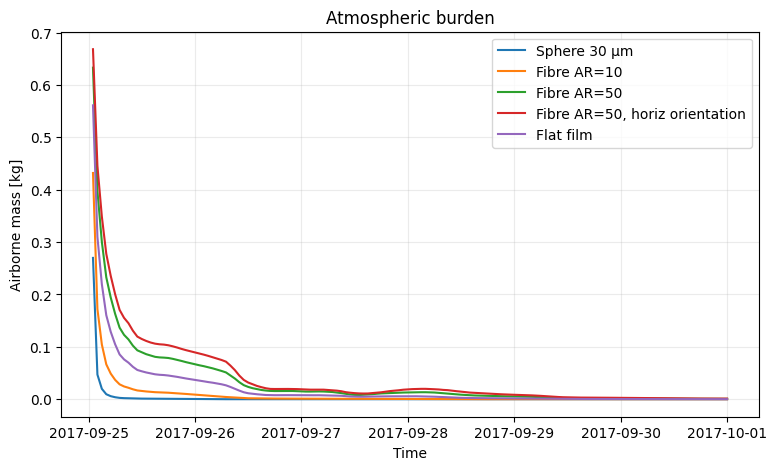

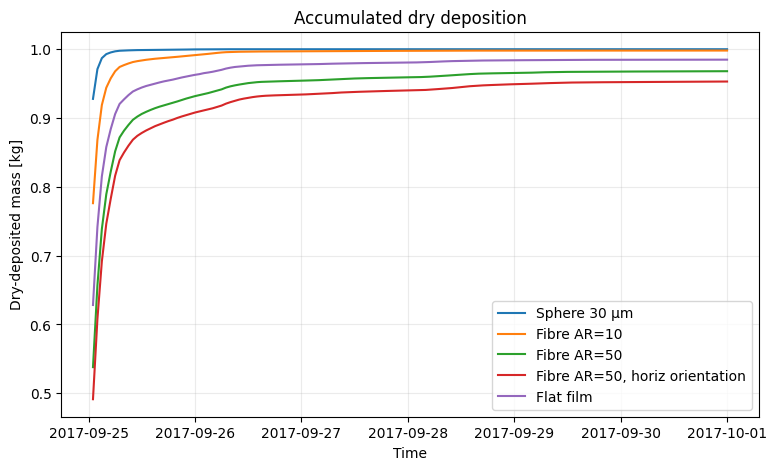

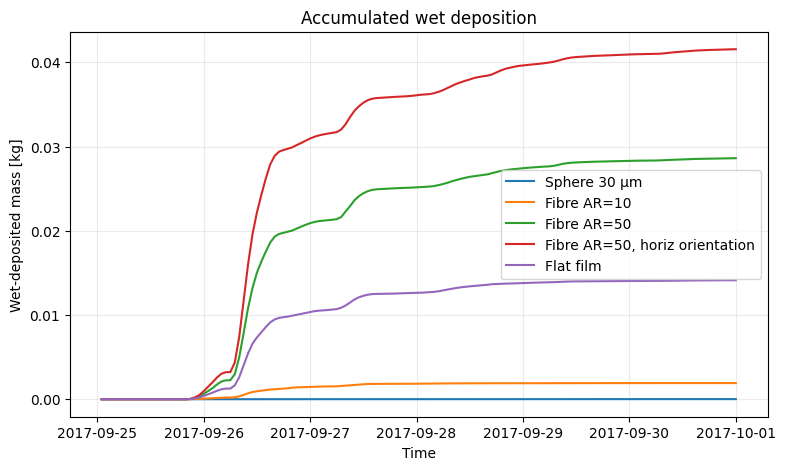

In [245]:
fig, ax = plt.subplots()
for label, d in diag.items():
    ax.plot(d.time, d.airborne_kg[0,0,:], label=label)
ax.set(title="Atmospheric burden", xlabel="Time", ylabel="Airborne mass [kg]")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots()
for label, d in diag.items():
    ax.plot(d.time, d.dry_deposited_kg[0,0,:], label=label)
ax.set(title="Accumulated dry deposition", xlabel="Time",
       ylabel="Dry-deposited mass [kg]")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots()
for label, d in diag.items():
    ax.plot(d.time, d.wet_deposited_kg[0,0,:], label=label)
ax.set(title="Accumulated wet deposition", xlabel="Time",
       ylabel="Wet-deposited mass [kg]")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Solution to point 5



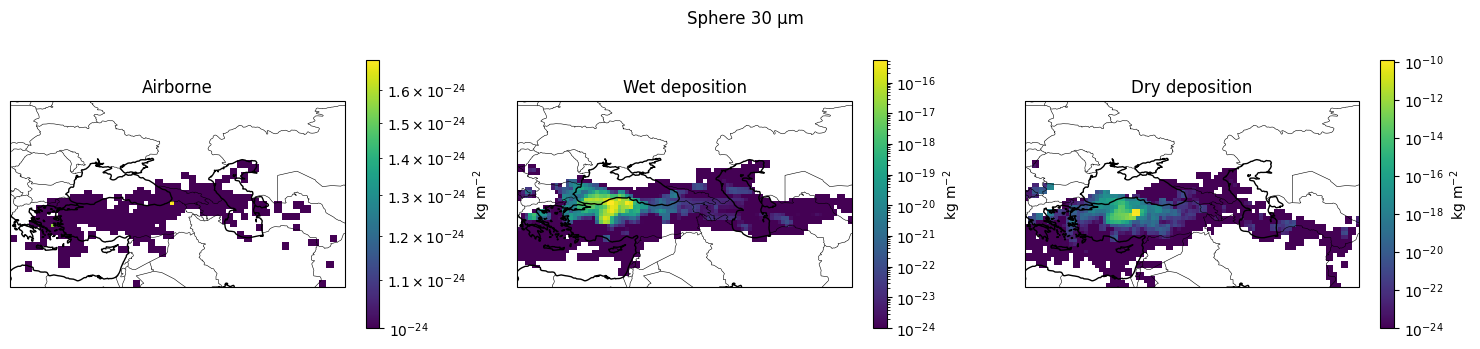

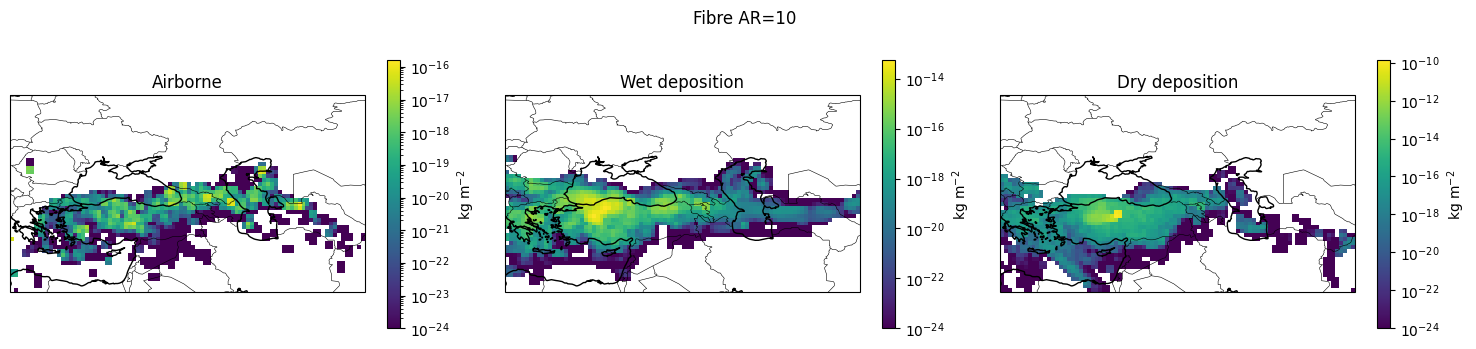

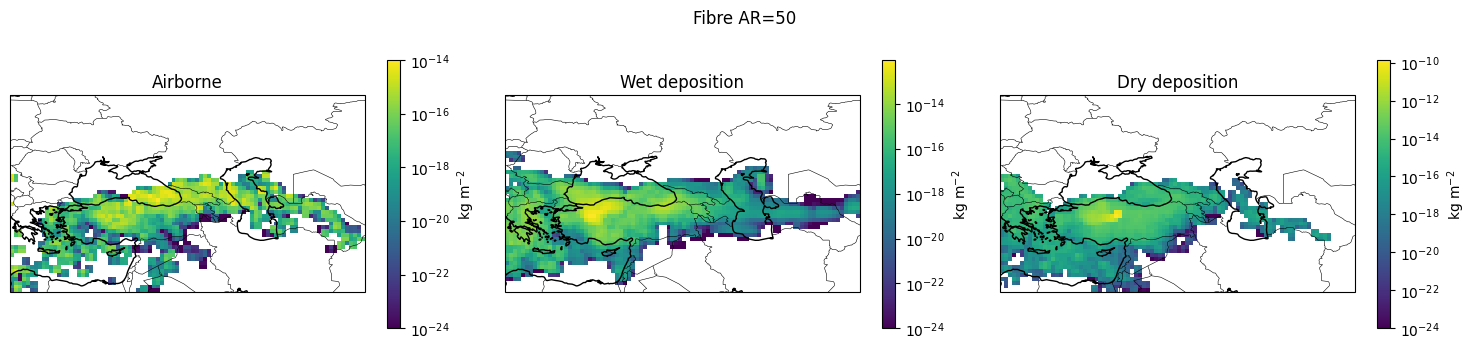

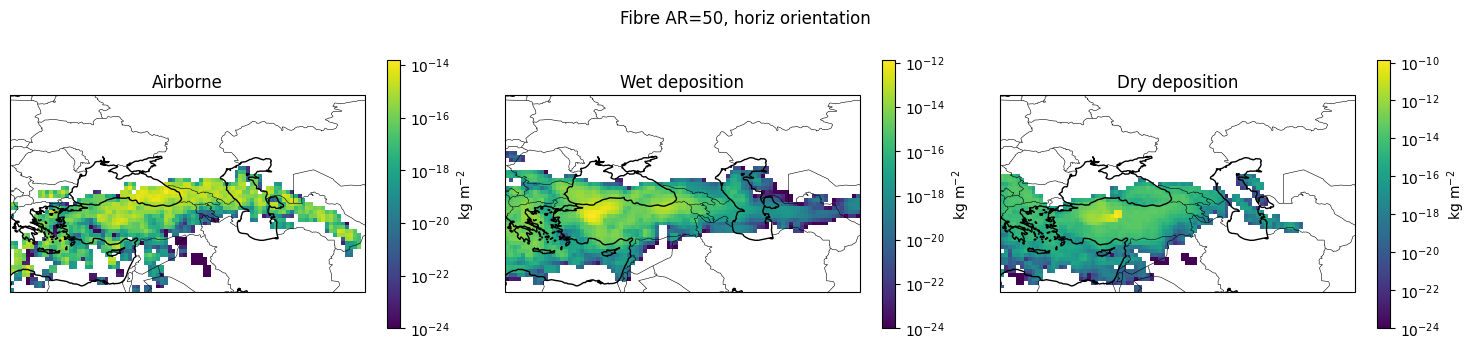

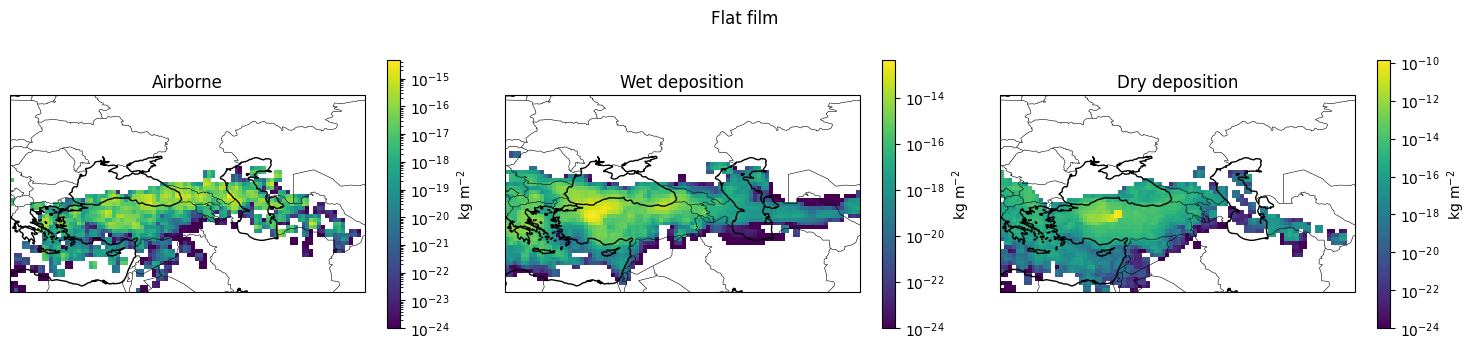

In [266]:
from matplotlib.colors import LogNorm
def column_burden(ds, timestep=-1):
    dz = layer_thickness(ds)
    return (ds["spec001_mr"].isel(time=timestep) * dz).sum("height") * 1e-12

def plot_fate(ds, label):
    # Airborne, wet deposition, dry deposition
    fields = {
        "Airborne": column_burden(ds),
        "Wet deposition": ds["WD_spec001"].isel(time=-1) * 1e-12,
        "Dry deposition": ds["DD_spec001"].isel(time=-1) * 1e-12
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), subplot_kw={"projection": ccrs.PlateCarree()})

    for ax, (title, field) in zip(axes, fields.items()):

        field = field.squeeze()
        norm = LogNorm(vmin=1e-24,vmax=field.max())
        mesh = ax.pcolormesh(field.longitude, field.latitude, field,cmap="viridis", norm=norm,transform=ccrs.PlateCarree())
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_title(title)

        fig.colorbar(mesh, ax=ax, label="kg m$^{-2}$", shrink=0.5)

    fig.suptitle(label,y=0.78)
    
    plt.tight_layout()
    plt.show()

for label, ds in datasets.items():
    plot_fate(ds, label)

## Solution to point 6

In [247]:
rows = []
for label, d in diag.items():
    last = d.isel(time=-1)
    airborne = float(last.airborne_kg)
    dry = float(last.dry_deposited_kg)
    wet = float(last.wet_deposited_kg)
    rows.append({
        "Case": label,
        "Airborne [kg]": airborne,
        "Dry deposited [kg]": dry,
        "Wet deposited [kg]": wet,
        "Airborne + deposited [kg]": airborne + dry + wet
    })

summary = pd.DataFrame(rows).set_index("Case")
summary

,Airborne [kg],Dry deposited [kg],Wet deposited [kg],Airborne + deposited [kg]
Case,,,,
Sphere 30 µm,1.664406e-14,0.999987,0.000012,0.999999
Fibre AR=10,3.071530e-06,0.998056,0.001918,0.999977
Fibre AR=50,6.807318e-04,0.968037,0.028612,0.997330
"Fibre AR=50, horiz orientation",1.170603e-03,0.953038,0.041548,0.995756
Flat film,1.256719e-04,0.984813,0.014125,0.999063


## 7. Vertical distribution of airborne material

So far we have looked at the horizontal distribution of the particles.
But does particle morphology also affect their **vertical distribution**?

We can calculate a latitude–height cross section of atmospheric concentration, averaged over all longitudes, at the last 5 time steps, to see how it behaves (by last 5 time steps I mean from 2017-09-30 20:00 until 2017-10-01 00:00)

## Solution to point 7

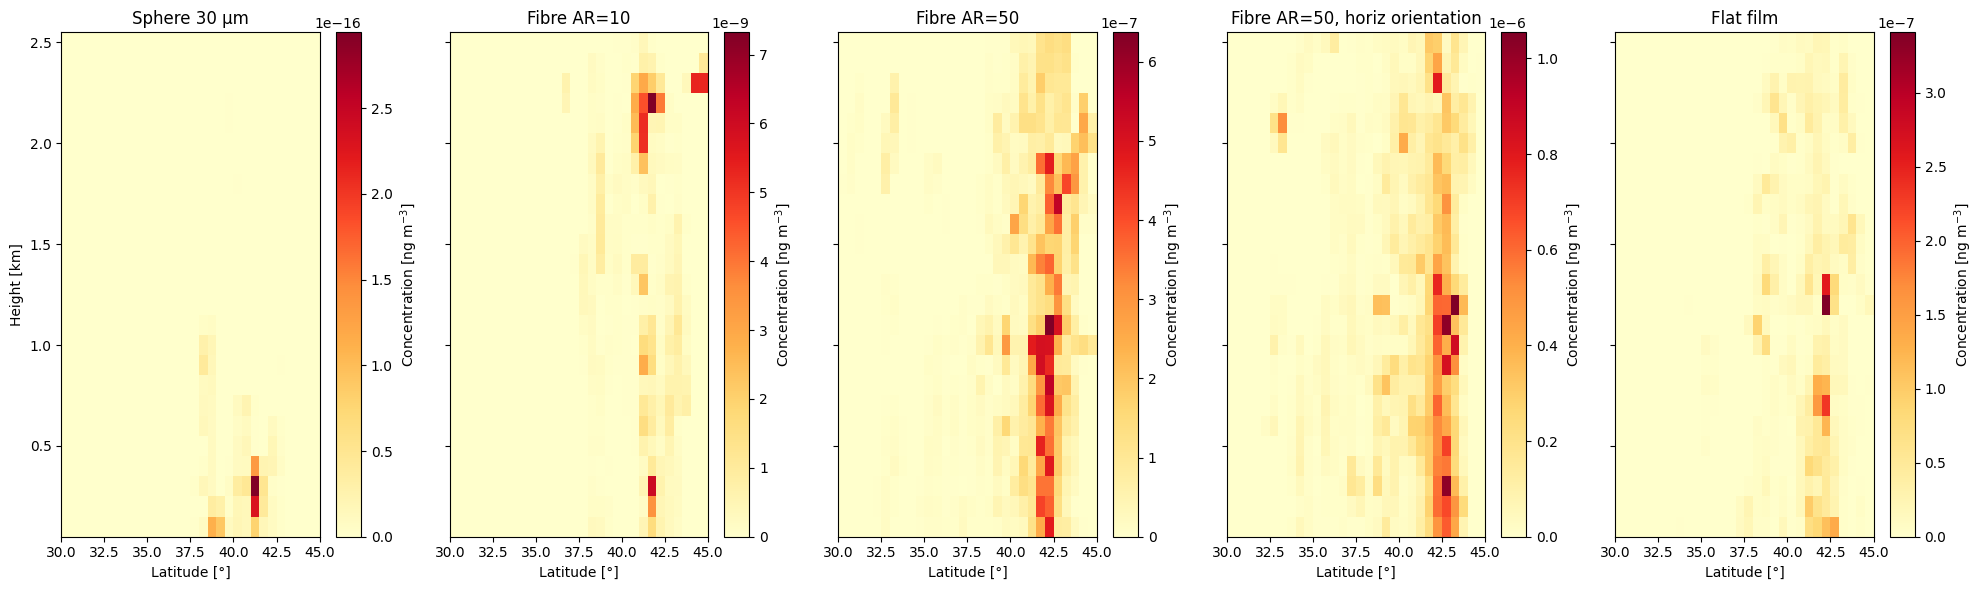

In [248]:
fig, axes = plt.subplots(
    1, len(datasets),
    figsize=(4 * len(datasets), 6),
    sharey=True
)

for ax, (label, ds) in zip(axes, datasets.items()):

    # Average over longitude:
    # the remaining dimensions are latitude and height
    vertical_section = (
        ds["spec001_mr"]
        .isel(time=slice(-5, None))
        .mean(dim=["time", "longitude"])
        .squeeze()
    )

    # Remove the singleton FLEXPART dimensions, if present
    vertical_section = vertical_section.squeeze()

    # Plot latitude vs height
    mesh = ax.pcolormesh(
        ds.latitude,
        ds.height / 1000,
        vertical_section,
        shading="auto",
        cmap="YlOrRd",
        vmin=0
    )

    ax.set_title(label)
    ax.set_xlabel("Latitude [°]")
    ax.set_xlim(30,45)
    plt.colorbar(
        mesh,
        ax=ax,
        label="Concentration [ng m$^{-3}$]"
    )

axes[0].set_ylabel("Height [km]")

plt.tight_layout()
plt.show()

# Questions for reflection

1. Which morphology appeared to remain airborne longest? Was your prediction correct?
2. Does changing **orientation** have an effect comparable to changing aspect ratio?
3. How does the **flat film** compare with the fibres and sphere, despite equal equivalent volume and density?
4. Why can wet deposition differ even though wet-scavenging parameters are identical?
5. If you look at the table produced in table 6, you'll notice that the total sum of airborne+deposited is <1. Can you guess why?